# Etalon Calibration Simulation

This notebook simulates the **fixed-wavelength calibration** step for a scanning Fabry–Pérot etalon.

Goal:
- hold the laser wavelength fixed
- simulate the etalon scan and photodiode response
- estimate **FSR per scan** by counting the main resonance peaks in one full scan


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# "Lab-like" settings
# -----------------------------
sample_rate = 5000          # Hz
duration = 5                # seconds
scan_period = 0.5           # seconds per sawtooth

# Etalon settings
FSR_GHz = 10.0              # physical etalon FSR (SA210)
FSR_per_scan_true = 8.0     # hidden truth for simulation only

# Fixed laser setting
lambda0_nm = 635.0
laser_delta_f_GHz = 0.0     # laser held fixed

# Signal / noise settings
signal_scale = 0.03
baseline = 0.004
white_noise_std = 0.0008
peak_sigma_GHz = 0.20

t = np.arange(0, duration, 1 / sample_rate)
print("Number of samples:", len(t))

Number of samples: 25000


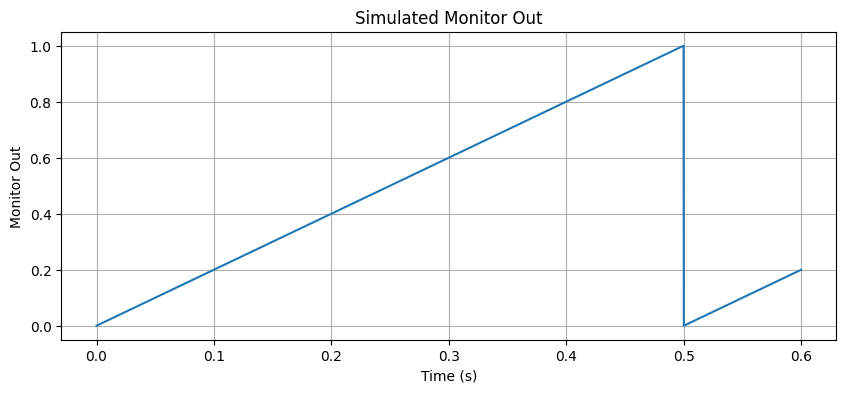

In [2]:
# Sawtooth phase from 0 to 1 every scan
scan_phase = (t % scan_period) / scan_period

# Simulated MONITOR OUT (normalized 0 to 1)
monitor_out = scan_phase

plt.figure(figsize=(10, 4))
plt.plot(t[:3000], monitor_out[:3000])
plt.xlabel("Time (s)")
plt.ylabel("Monitor Out")
plt.title("Simulated Monitor Out")
plt.grid(True)
plt.show()

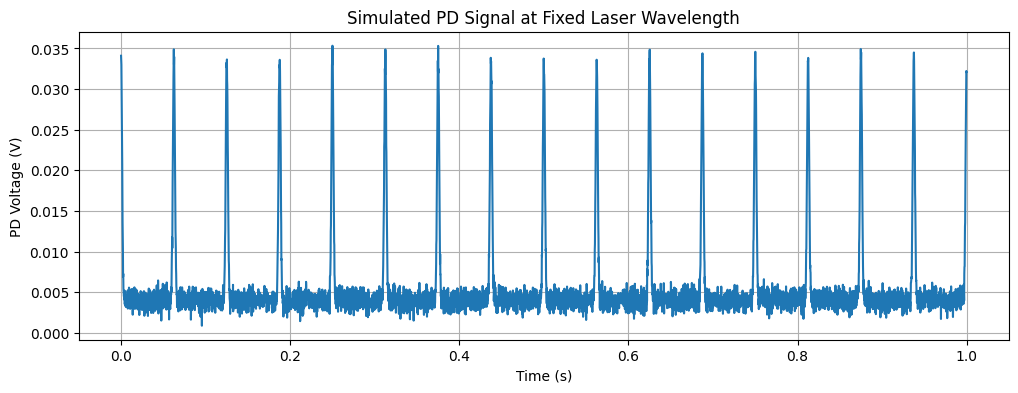

In [3]:
scan_span_GHz = FSR_per_scan_true * FSR_GHz
scan_frequency_GHz = scan_phase * scan_span_GHz

def wrapped_distance(x, period):
    return np.minimum(np.mod(x, period), period - np.mod(x, period))

# Distance from current scan position to nearest etalon resonance
dist_to_res_GHz = wrapped_distance(scan_frequency_GHz - laser_delta_f_GHz, FSR_GHz)

ideal_intensity = np.exp(-(dist_to_res_GHz**2) / (2 * peak_sigma_GHz**2))

# Add simple noise
rng = np.random.default_rng(0)
pd_signal = (
    baseline
    + signal_scale * ideal_intensity
    + rng.normal(0, white_noise_std, size=len(t))
)

plt.figure(figsize=(12, 4))
plt.plot(t[:5000], pd_signal[:5000])
plt.xlabel("Time (s)")
plt.ylabel("PD Voltage (V)")
plt.title("Simulated PD Signal at Fixed Laser Wavelength")
plt.grid(True)
plt.show()

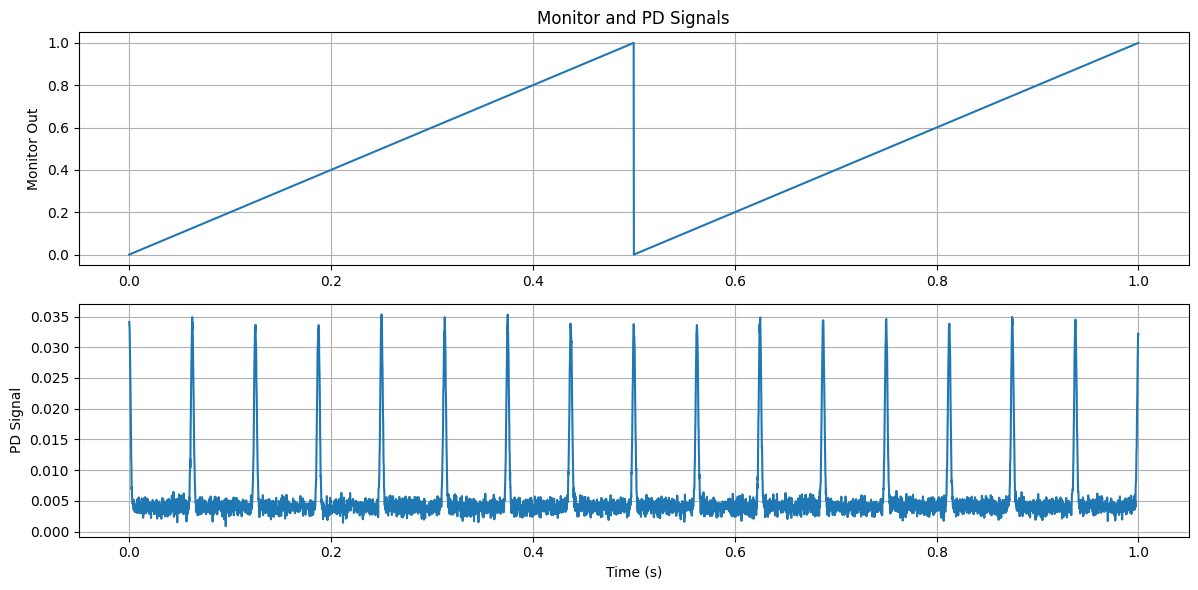

In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t[:5000], monitor_out[:5000])
plt.ylabel("Monitor Out")
plt.title("Monitor and PD Signals")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t[:5000], pd_signal[:5000])
plt.xlabel("Time (s)")
plt.ylabel("PD Signal")
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
dmon = np.diff(monitor_out)

# Sawtooth reset = large negative jump
reset_idx = np.where(dmon < -0.5)[0] + 1

scan_boundaries = np.concatenate(([0], reset_idx, [len(t) - 1]))

print("Estimated number of scans:", len(scan_boundaries) - 1)
print("First few boundaries:", scan_boundaries[:10])

Estimated number of scans: 10
First few boundaries: [    0  2500  5000  7500 10000 12500 15000 17500 20000 22500]


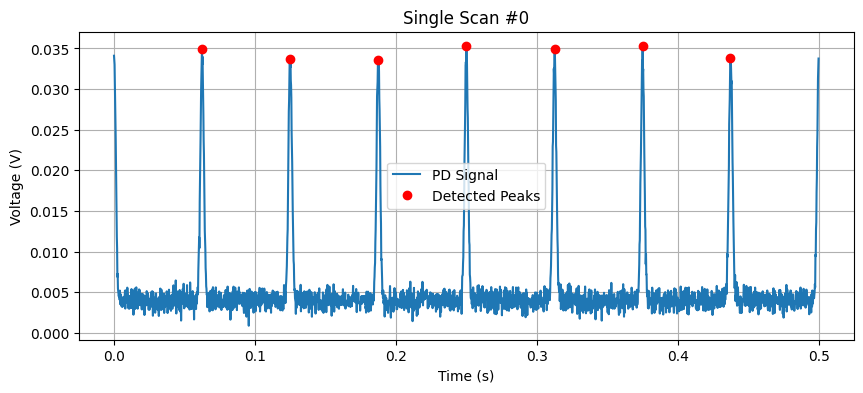

Number of detected peaks in this scan: 7


In [6]:
scan_index = 0

s = scan_boundaries[scan_index]
e = scan_boundaries[scan_index + 1]

seg_t = t[s:e]
seg_pd = pd_signal[s:e]

# Tune prominence if needed
peaks, props = find_peaks(seg_pd, prominence=0.005)

plt.figure(figsize=(10, 4))
plt.plot(seg_t, seg_pd, label="PD Signal")
plt.plot(seg_t[peaks], seg_pd[peaks], "ro", label="Detected Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Single Scan #{scan_index}")
plt.grid(True)
plt.legend()
plt.show()

print("Number of detected peaks in this scan:", len(peaks))

In [7]:
FSR_per_scan_est = len(peaks)

print("True FSR_per_scan:", FSR_per_scan_true)
print("Estimated FSR_per_scan:", FSR_per_scan_est)

True FSR_per_scan: 8.0
Estimated FSR_per_scan: 7


In [8]:
peak_counts = []

for i in range(len(scan_boundaries) - 1):
    s = scan_boundaries[i]
    e = scan_boundaries[i + 1]
    seg_pd = pd_signal[s:e]

    local_peaks, _ = find_peaks(seg_pd, prominence=0.005)
    peak_counts.append(len(local_peaks))

peak_counts = np.array(peak_counts)

print("Peak counts by scan:", peak_counts)
print("Mean estimated FSR_per_scan:", np.mean(peak_counts))
print("Median estimated FSR_per_scan:", np.median(peak_counts))

Peak counts by scan: [ 7  7  7  7  7  7  8  7 10  7]
Mean estimated FSR_per_scan: 7.4
Median estimated FSR_per_scan: 7.0


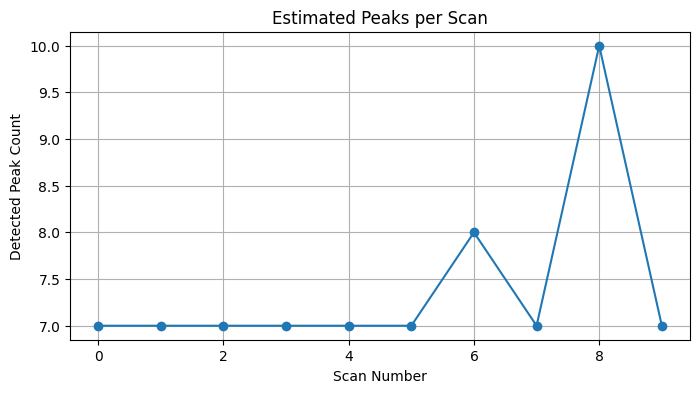

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(peak_counts)), peak_counts, "o-")
plt.xlabel("Scan Number")
plt.ylabel("Detected Peak Count")
plt.title("Estimated Peaks per Scan")
plt.grid(True)
plt.show()